# Wasserstein GAN (WGAN) Implementation in PyTorch

This notebook implements a **Wasserstein Generative Adversarial Network (WGAN)** using PyTorch to generate handwritten digit images similar to the MNIST dataset.

### Learning Objectives:
- Understand the improvements of WGAN over standard GANs
- Learn about the Wasserstein distance (Earth Mover's Distance)
- Implement a Critic network instead of a Discriminator
- Apply weight clipping for Lipschitz constraint
- Train more stable adversarial networks

### What is a WGAN?
Wasserstein GANs address key problems in standard GAN training:
1. **Training Stability**: More stable gradients throughout training
2. **Mode Collapse**: Reduced tendency to generate limited variety
3. **Meaningful Loss**: Loss correlates with sample quality

### Key Differences from Standard GAN:
- **Critic** (instead of Discriminator): Outputs a score rather than probability
- **Wasserstein Loss**: Measures Earth Mover's Distance between distributions
- **Weight Clipping**: Enforces Lipschitz constraint (weights bounded in [-c, c])
- **No Sigmoid**: Critic outputs unbounded scores
- **More Critic Updates**: Train critic multiple times per generator update

In [1]:
import torch
import torch.nn as nn
import numpy as np
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor, Compose
from IPython import display

In [3]:
batch_size = 128

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)

Using device: cuda


In [4]:
mnist_train = MNIST("./data", download=True, transform=Compose([ToTensor(), lambda x: x.to(device)]))
mnist_test = MNIST("./data", download=True, train=False, transform=Compose([ToTensor(), lambda x: x.to(device)]))

mnist_train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.61MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.12MB/s]


### Helper function for generate images

In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot(samples):
    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis("off")
        plt.imshow(sample.reshape(28, 28), cmap="Greys_r")

    return fig

## Generator Network Architecture

The **Generator** creates synthetic images from random noise using transpose convolutions.

### Architecture:
1. **Input**: Random noise vector of size 128 (reshaped to 128×1×1)
2. **Layer 0**: ConvTranspose2d (128→64 channels, 4×4 kernel, stride=2) → BatchNorm → ReLU
   - Output: 64×2×2
3. **Layer 1**: ConvTranspose2d (64→32 channels, 7×7 kernel) → BatchNorm → ReLU
   - Output: 32×7×7
4. **Layer 2**: ConvTranspose2d (32→16 channels, 4×4 kernel, stride=2) → BatchNorm → ReLU
   - Output: 16×14×14
5. **Layer 3**: ConvTranspose2d (16→1 channel, 4×4 kernel, stride=2) → Sigmoid
   - Output: 1×28×28 (final image)

### Key Features:
- **Deeper architecture**: More layers than basic GAN for better quality
- **Sigmoid output**: Ensures pixel values in [0, 1] range
- **Progressive upsampling**: Gradually builds image from noise

In [6]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.z_size = 128

        # Generator

        self.gen_layer0 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        self.gen_layer1 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )
        self.gen_layer2 = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
        )

        self.gen_layer3 = nn.Sequential(
            torch.nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=3),
            nn.Sigmoid()
        )


    def forward(self, x):
        x = x.view(-1, self.z_size, 1, 1)
        x = self.gen_layer0(x)
        x = self.gen_layer1(x)
        x = self.gen_layer2(x)
        x = self.gen_layer3(x)
        return x

    def sample(self, n):
        z = torch.randn(n, self.z_size)
        return z

    def generate(self, n=1):
        z = self.sample(n).to(device)
        return self.forward(z)

### Critic Network Architecture

The **Critic** (not Discriminator!) evaluates how "real" an image looks by outputting a score.

### Architecture:
1. **Input**: Image of size 1×28×28
2. **Layer 1**: Conv2d (1→16 channels, 3×3 kernel, stride=2) → BatchNorm → LeakyReLU
   - Output: 16×14×14
3. **Layer 2**: Conv2d (16→32 channels, 3×3 kernel, stride=2) → BatchNorm → LeakyReLU
   - Output: 32×7×7
4. **Layer 3**: Conv2d (32→64 channels, 7×7 kernel) → BatchNorm → LeakyReLU
   - Output: 64×1×1
5. **Classifier 1**: Linear (64→256) → ReLU
6. **Classifier 2**: Linear (256→1)
   - Output: **Unbounded score** (not probability!)

### WGAN-Specific Features:
- **No Sigmoid**: Outputs real-valued scores, not probabilities
- **Fully connected layers**: Additional capacity after convolutions
- **Weight clipping**: Will be applied during training to maintain Lipschitz constraint

In [7]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()

        self.dis_layer1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(),
        )

        self.dis_layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
        )

        self.dis_layer3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
        )

        self.dis_clf1 = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU()
        )

        self.dis_clf2 = nn.Linear(256, 1)


    def forward(self, x):
        x = self.dis_layer1(x)
        x = self.dis_layer2(x)
        x = self.dis_layer3(x)
        x = x.view(-1, 64)

        x = self.dis_clf1(x)
        x = self.dis_clf2(x)
        return x


### WGAN Training Functions

### Wasserstein Loss:
The critic maximizes: $\mathbb{E}[C(x_{real})] - \mathbb{E}[C(x_{fake})]$

This measures the **Wasserstein Distance** (Earth Mover's Distance) between real and generated distributions.

### Training Process:

**1. train_critic():**
- Updates the Critic multiple times (default: 5 iterations)
- Loss: Minimize $-(\text{mean}(C(real)) - \text{mean}(C(fake)))$
- **Weight Clipping**: After each update, clip all weights to [-0.01, 0.01]
  - This enforces the Lipschitz constraint required by Wasserstein distance
  - Alternative: Use gradient penalty (WGAN-GP)

**2. train_generator():**
- Updates the Generator to maximize Critic score on fake images
- Loss: Minimize $-\text{mean}(C(fake))$

### Key Differences from Standard GAN:
- ✓ No sigmoid → unbounded scores
- ✓ No log in loss → more stable gradients
- ✓ Weight clipping → Lipschitz constraint
- ✓ Multiple critic updates → better gradient information

In [8]:
def train_critic(crit, real_data, gen, critic_iters=5):

    crit.train()
    total_loss = 0
    for _ in range(critic_iters):
        crit_opt.zero_grad()

        real_pred = crit(real_data)
        fake_data = gen.generate(real_data.shape[0]).to(device)
        fake_pred = crit(fake_data)

        loss = -(torch.mean(real_pred) - torch.mean(fake_pred))
        loss.backward()

        crit_opt.step()

        # clip weights
        for p in crit.parameters():
            p.data.clamp_(-0.01, 0.01)

        total_loss += loss.detach()

    return total_loss / critic_iters


def train_generator(gen, crit):
    gen.train()
    gen_opt.zero_grad()
    fake_data = gen.generate(batch_size)

    fake_pred = crit(fake_data)
    loss = -torch.mean(fake_pred)

    loss.backward()

    gen_opt.step()

    return loss.detach()

### Main Training Loop

The training loop implements the WGAN algorithm with real-time visualization:

### Training Strategy:
1. For each batch of real images:
   - Generate fake images from random noise
   - Update **Critic** 5 times (more than Generator)
   - Update **Generator** once
   
2. Every 100 steps:
   - Display current generated samples
   - Show Critic and Generator losses
   - Save images to track progress

### Monitoring Training:
- **Critic Loss**: Should stabilize (negative value is normal!)
- **Generator Loss**: Should decrease as it fools the Critic better
- **Generated Images**: Should improve quality over time

The loss values have different meanings than standard GAN - they represent Wasserstein distance approximations.

In [9]:
def train(gen, crit, train_loader, epoch_start=0, epochs=10, samples=None):
    for epoch in range(epoch_start, epoch_start + epochs):
        for i, (real_data, _) in enumerate(train_loader):
            real_data = real_data.to(device)

            loss1 = train_critic(crit, real_data, gen)
            loss2 = train_generator(gen, crit)

            if i % 100 == 0:
                print(
                    f"Epoch: {epoch}, Step: {i}, critic Loss: {loss1}, Generator Loss: {loss2}"
                )

                gen.eval()
                generated = gen.forward(samples).detach().cpu().numpy()

                display.clear_output(wait=True)
                fig = plot(generated)
                fig.suptitle(
                    f"Epoch: {epoch}, Step: {i}\n CLoss: {loss1:2.4f}, GLoss: {loss2:2.4f}"
                )
                display.display(fig)
                plt.savefig(f"images/wgan_conv_e{epoch}_s{i}.png")

                plt.close(fig)

### Initialize Models and Optimizers

Create Generator and Critic instances and setup optimizers.

### Hyperparameters:
- **Learning Rate**: 0.00005 (lower than standard GAN for stability)
- **Optimizer**: Adam (though RMSprop is also commonly used for WGAN)

The low learning rate helps maintain the Lipschitz constraint and prevents instability.

In [10]:
gen = Generator().to(device)
crit = Critic().to(device)

gen_opt = torch.optim.Adam(gen.parameters(), lr=0.00005)
crit_opt = torch.optim.Adam(crit.parameters(), lr=0.00005)

### Prepare for Training

Set training parameters and generate fixed noise samples for consistent visualization across epochs.

- **epoch**: Tracking variable for resumable training
- **num_epochs**: Total epochs to train (100 is typical for MNIST)
- **samples**: Fixed noise vectors to visualize progress consistently

In [11]:
epoch = 0
num_epochs = 100

samples = gen.sample(16).to(device)

### Train the WGAN

**Execute this cell to start training!**

Training for 100 epochs will take considerable time (30+ minutes depending on hardware). The cell will:
- Display generated images every 100 steps
- Print Critic and Generator losses
- Save images to `images/` folder for later review

### What to Observe:
1. **Early epochs (0-10)**: Noisy blobs, high losses
2. **Middle epochs (10-50)**: Recognizable shapes emerge
3. **Later epochs (50-100)**: Clear, digit-like images

You can interrupt and resume training by re-running this cell (epoch counter persists).

**Note**: Make sure the `images/` directory exists before running!

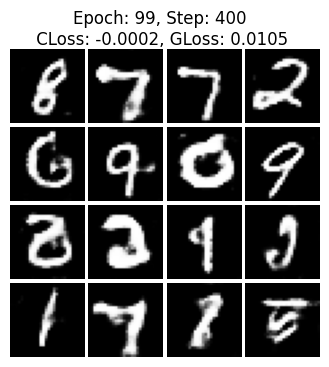

In [13]:
train(gen, crit, mnist_train_loader, epoch_start=epoch, epochs=num_epochs, samples = samples)
epoch += num_epochs